In [10]:
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Notebook used to plot the AUROC curves for the Superviz25-SQL article

In [11]:
from pathlib import Path
from typing import Literal
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import logging

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    roc_curve,
    auc,
)


In [12]:
def load_csv_files(folder_path):
    csv_dataframes = {}
    
    folder_path = Path(folder_path)
    for file_path in sorted(folder_path.rglob("*.csv")):
        try:
            relative_path = file_path.relative_to(folder_path)
            key_name = str(relative_path)
            
            df = pd.read_csv(file_path)
            csv_dataframes[key_name] = df
            
            print(f"Loaded: {key_name} - Shape: {df.shape}")
            
        except Exception as e:
            print(f"Error loading {file_path}: {str(e)}")
    
    return csv_dataframes

base_folder_name = "/home/gquetel/experiences-results/dataset-generation/unsupervized-v7/output/"

## AUPRC 

In [ ]:
folder_path = f"{base_folder_name}pr_curves/"


def plot_pr_curves_from_dict(
    dataframes_dict: dict,
    output_folder_path="./output/models/pr_curves/",
    suffix: str = "",
    prevalence_value=None,
):
    fig, ax = plt.subplots(figsize=(12, 10))

    folder_path = Path(output_folder_path)
    folder_path.mkdir(exist_ok=True, parents=True)

    line_styles = [
        "-",
        "--",
        (0, (1, 5)),
        "-",
        "--",
        (0, (1, 5)),
        "-",
        "--",
        (0, (1, 5)),
        # (0, (1, 1)),  # densely dotted
        # (0, (1, 5)),  # dotted
        # (0, (5, 1)),  # densely dashed
        # (0, (3, 1, 1, 1)),  # densely dashdotted
        # "-",
        # "--",
    ]
    thickness = [1.5,1.5,2,1.5,1.5,2,1.5,1.5,2]
    colors = [
        "#ff7f00",
        "#ff7f00",
        "#ff7f00",
        "#377eb8",
        "#377eb8",
        "#377eb8",
        "#4daf4a",
        "#4daf4a",
        "#4daf4a",

    ]
    i = 0
    for filename, df in dataframes_dict.items():
        model_name = filename.replace(".csv", "")
        # Rename for consistency with paper
        model_name = model_name.replace("SecureBERT ","SecureBERT\n")
        model_name = model_name.replace("and ","+ ")

        model_name = model_name.replace("CountVectorizer ","CountVectorizer\n")
        
        precision = df["precision"].values
        recall = df["recall"].values

        auprc = auc(recall, precision)
        ax.plot(
            recall,
            precision,
            label=f"{model_name} ({auprc:.4f})",
            linestyle=line_styles[i],
            linewidth=thickness[i],
            color=colors[i]
        )
        i += 1

    if prevalence_value is not None:
        x = [0, 1]
        y = [prevalence_value] * len(x)
        ax.plot(
            x,
            y,
            "k--",
            alpha=0.7,
            label=f" Random Classifier \n({prevalence_value:.4f})",
        )

    # Customize plot
    ax.set_xlabel("Recall", fontsize=25)
    ax.set_ylabel("Precision", fontsize=25)
    # ax.set_title("AUPRC Comparison", fontsize=24)
    ax.legend(bbox_to_anchor=(0.5, -0.60), loc="lower center", prop={"size": 22},ncol=2)
    ax.grid(True, alpha=0.3)

    # Save plot
    output_filename = f"auprc_curves{suffix}.png"
    plt.savefig(folder_path / output_filename, dpi=300, bbox_inches="tight")
    plt.show()

In [14]:
d = load_csv_files(folder_path=folder_path)
chall_df = {}
all_df = {}

for filename, df in d.items():
    # Remove .csv extension for checking
    base_name = filename.replace(".csv", "")
    
    if base_name.endswith("_chall"):
        chall_df[filename] = df
    else:
        all_df[filename] = df

Loaded: CountVectorizer and AE.csv - Shape: (402868, 2)
Loaded: CountVectorizer and LOF .csv - Shape: (1075186, 2)
Loaded: CountVectorizer and OCSVM.csv - Shape: (1222872, 2)
Loaded: Li and AE.csv - Shape: (555005, 2)
Loaded: Li and LOF.csv - Shape: (427534, 2)
Loaded: Li and OCSVM.csv - Shape: (368437, 2)
Loaded: SBERT and AE.csv - Shape: (2053607, 2)
Loaded: SBERT and LOF.csv - Shape: (1564357, 2)
Loaded: SBERT and OCSVM.csv - Shape: (2119611, 2)


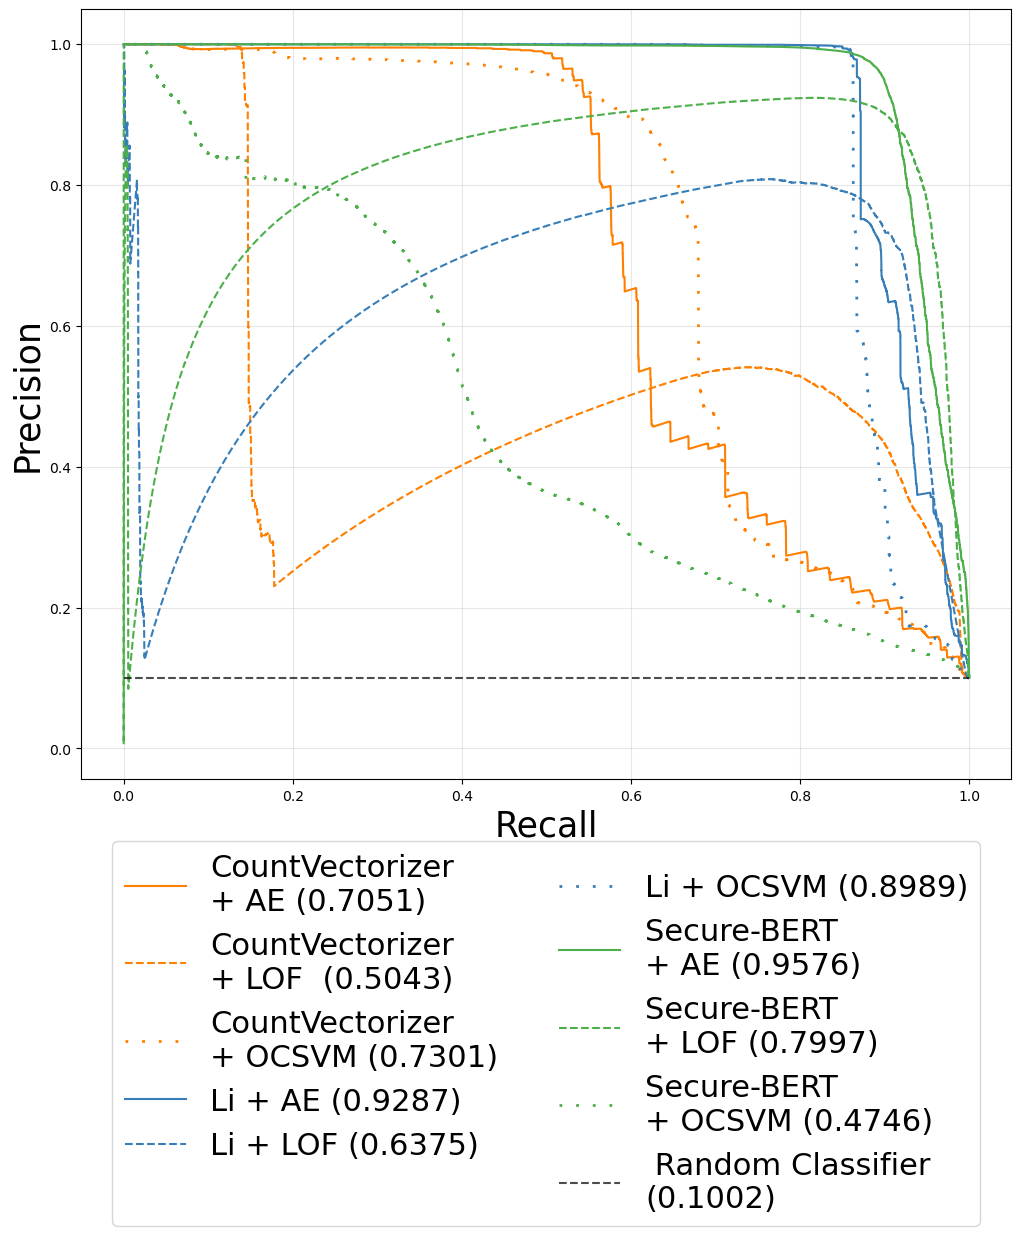

In [15]:
plot_pr_curves_from_dict(all_df,output_folder_path=folder_path,suffix="", prevalence_value=0.1002)

## AUROC

In [ ]:
def plot_roc_curves_from_dict(
    dataframes_dict: dict,
    output_folder_path="./output/models/roc_curves/",
    suffix: str = "",
):
    fig, ax = plt.subplots(figsize=(12, 10))

    folder_path = Path(output_folder_path)
    folder_path.mkdir(exist_ok=True, parents=True)
    line_styles = [
        "-",
        "--",
        (0, (1, 5)),
        "-",
        "--",
        (0, (1, 5)),
        "-",
        "--",
        (0, (1, 5)),
        # (0, (1, 1)),  # densely dotted
        # (0, (1, 5)),  # dotted
        # (0, (5, 1)),  # densely dashed
        # (0, (3, 1, 1, 1)),  # densely dashdotted
        # "-",
        # "--",
    ]
    thickness = [1.5, 1.5, 2, 1.5, 1.5, 2, 1.5, 1.5, 2]
    colors = [
        "#ff7f00",
        "#ff7f00",
        "#ff7f00",
        "#377eb8",
        "#377eb8",
        "#377eb8",
        "#4daf4a",
        "#4daf4a",
        "#4daf4a",
    ]
    i = 0

    for filename, df in dataframes_dict.items():
        model_name = filename.replace(".csv", "")
        # Rename for consistency with paper
        model_name = model_name.replace("SecureBERT ","SecureBERT\n")
        model_name = model_name.replace("and ","+ ")

        model_name = model_name.replace("CountVectorizer ","CountVectorizer\n")

        fpr = df["fpr"].values
        tpr = df["tpr"].values

        auprc = auc(fpr, tpr)
        ax.plot(
            fpr,
            tpr,
            label=f"{model_name} ({auprc:.4f})",
            linestyle=line_styles[i],
            linewidth=thickness[i],
            color=colors[i],
        )
        i += 1

    ax.plot([0, 1], [0, 1], "k--", alpha=0.6, label="Random Classifier \n(0.5000)")

    # Customize plot
    ax.set_xlabel("False Positive Rate",fontsize=25)
    ax.set_ylabel("True Positive Rate",fontsize=25)
    # ax.set_title("ROC Comparison",fontsize=24)
    ax.legend(bbox_to_anchor=(0.5, -0.60), loc="lower center", prop={"size": 22},ncol=2)
    ax.grid(True, alpha=0.3)

    # Save plot
    output_filename = f"roc_curves{suffix}.png"
    plt.savefig(folder_path / output_filename, dpi=300, bbox_inches="tight")
    plt.show()

In [17]:
folder_path = f"{base_folder_name}roc_curves/"

d = load_csv_files(folder_path=folder_path)
chall_df = {}
all_df = {}

for filename, df in d.items():
    # Remove .csv extension for checking
    base_name = filename.replace(".csv", "")

    if base_name.endswith("_chall"):
        chall_df[filename] = df
    else:
        all_df[filename] = df

Loaded: CountVectorizer and AE.csv - Shape: (197165, 2)
Loaded: CountVectorizer and LOF .csv - Shape: (304462, 2)
Loaded: CountVectorizer and OCSVM.csv - Shape: (464017, 2)
Loaded: Li and AE.csv - Shape: (190656, 2)
Loaded: Li and LOF.csv - Shape: (179660, 2)
Loaded: Li and OCSVM.csv - Shape: (162032, 2)
Loaded: SBERT and AE.csv - Shape: (486256, 2)
Loaded: SBERT and LOF.csv - Shape: (743543, 2)
Loaded: SBERT and OCSVM.csv - Shape: (735995, 2)


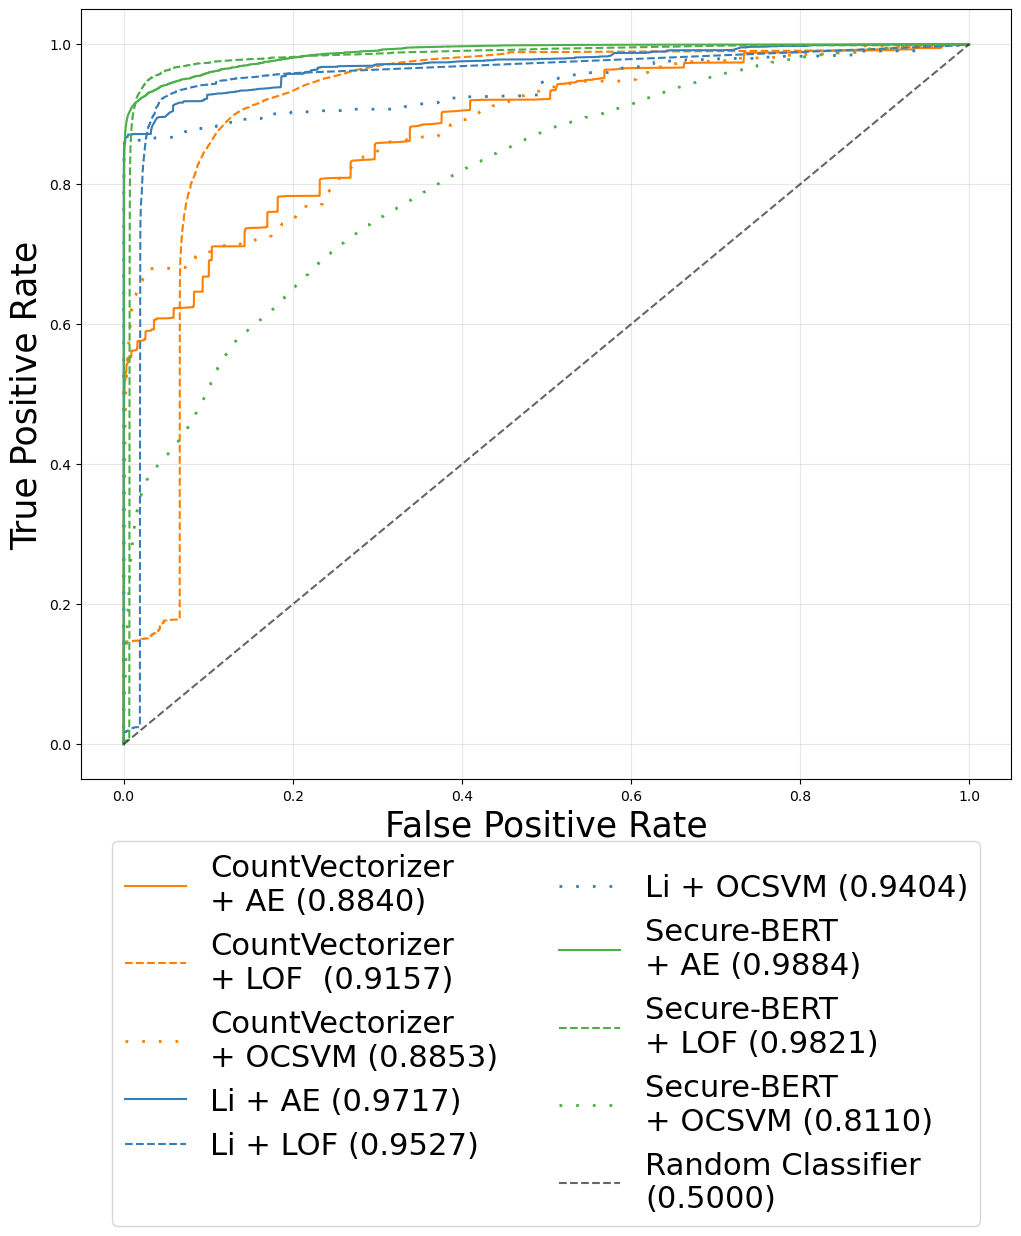

In [18]:
plot_roc_curves_from_dict(all_df,output_folder_path=folder_path,suffix="")
